In [85]:
!pip install pymupdf nltk requests
!pip install paho-mqtt requests matplotlib

In [86]:
# Imports
import re
import fitz  # PyMuPDF
import requests
from collections import defaultdict
from nltk.stem import PorterStemmer
import matplotlib.pyplot as plt
from IPython.display import HTML, display

In [87]:

import os, glob, sys, subprocess
try:
    import gdown
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=False)
    import gdown

DRIVE_FOLDER_URL = "https://drive.google.com/drive/folders/1FfLT9U8AKaxLAWY02MhNeS-ZhlJqjo2N"

LOCAL_DIR = "/content/papers"
os.makedirs(LOCAL_DIR, exist_ok=True)

gdown.download_folder(DRIVE_FOLDER_URL, output=LOCAL_DIR, quiet=False, use_cookies=False)

pdf_paths = sorted(glob.glob(os.path.join(LOCAL_DIR, "**", "*.pdf"), recursive=True))
assert pdf_paths, (
    f"No PDFs downloaded into {LOCAL_DIR}. "
    "Check that the Drive folder is shared"
)

# Build the article list from the downloaded files
ARTICLES = []
for i, p in enumerate(pdf_paths, start=1):
    title = os.path.splitext(os.path.basename(p))[0]
    ARTICLES.append({"doc_id": f"doc{i}", "title": title, "url": p})

DOC_LINKS = {a["doc_id"]: a["url"] for a in ARTICLES}
DOC_TITLES = {a["doc_id"]: a["title"] for a in ARTICLES}
DOC_TEXT = {}

print(f"\nDownloaded {len(ARTICLES)} PDF(s):")
for a in ARTICLES:
    print(f"  {a['doc_id']}: {a['title']}")


Retrieving folder contents


Processing file 1zzpXQeEFkmLytrY0KOd4F7xNBSo_wdwx Anthracnose disease of Swiss cheese plant [Monstera deliciosa Liebm.].pdf
Processing file 1vsWtMF_T564HLLcj6VOb68FMtcuII6FV In vitro Antioxidant Activity and Total Phenolic Content of Monstera.pdf
Processing file 1Q-_9E9D80worlxjm068pXRD17LTYdHdf Influence of some chemical compounds as.pdf
Processing file 1BR6XI0PmJu2IVtJetmr4bghi4YpJOxkx Micropropagation and Acclimatization of Monstera deliciosa Liebm. ‘Thai Constellation.pdf
Processing file 1MwQyqNqKuP-sTB69qCwGbHQGQB0G0pXA Phytochemistry and pharmacological potential of.pdf


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1zzpXQeEFkmLytrY0KOd4F7xNBSo_wdwx
To: /content/papers/Anthracnose disease of Swiss cheese plant [Monstera deliciosa Liebm.].pdf
100%|██████████| 483k/483k [00:00<00:00, 10.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1vsWtMF_T564HLLcj6VOb68FMtcuII6FV
To: /content/papers/In vitro Antioxidant Activity and Total Phenolic Content of Monstera.pdf
100%|██████████| 358k/358k [00:00<00:00, 9.00MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Q-_9E9D80worlxjm068pXRD17LTYdHdf
To: /content/papers/Influence of some chemical compounds as.pdf
100%|██████████| 341k/341k [00:00<00:00, 17.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1BR6XI0PmJu2IVtJetmr4bghi4YpJOxkx
To: /content/papers/Micropropagation and Acclimatization of Monstera deliciosa Liebm. ‘Thai Constellation.pdf
100%|██████████| 1.27M/1.27M [00:00<0


Downloaded 5 PDF(s):
  doc1: Anthracnose disease of Swiss cheese plant [Monstera deliciosa Liebm.]
  doc2: In vitro Antioxidant Activity and Total Phenolic Content of Monstera
  doc3: Influence of some chemical compounds as
  doc4: Micropropagation and Acclimatization of Monstera deliciosa Liebm. ‘Thai Constellation
  doc5: Phytochemistry and pharmacological potential of



Download completed


In [88]:
HEADERS = {"User-Agent": "Mozilla/5.0"}

def fetch_pdf_text(source):
    if isinstance(source, str) and source.lower().startswith("http"):
        resp = requests.get(source, headers=HEADERS, timeout=30)
        resp.raise_for_status()
        doc = fitz.open(stream=resp.content, filetype="pdf")
    else:
        doc = fitz.open(source)  # local file
    text = " ".join(page.get_text() for page in doc)
    doc.close()
    return re.sub(r"\s+", " ", text).strip()

In [89]:
STOP_WORDS = {
    "a", "an", "the", "and", "or", "of", "to", "in", "on", "for", "with",
    "as", "by", "is", "are", "was", "were", "be", "been", "that", "this",
    "these", "those", "we", "our", "it", "its", "from", "at", "which",
    "can", "using", "used", "study", "paper", "results", "method", "based",
    "show", "shows", "each", "such", "yet", "also", "may", "between",
}

## **Text processing**

In [90]:

stemmer = PorterStemmer()

def tokenize(text):
    # lowercase alphabetic tokens only
    return re.findall(r"[a-z]+", text.lower())

def clean_tokens(tokens):
    return [stemmer.stem(t) for t in tokens
            if t not in STOP_WORDS and len(t) > 2]


In [91]:
# significant words we chose to index

INDEX_TERMS = {
    "monstera", "deliciosa", "anthracnose", "colletotrichum", "gloeosporioides",
    "conidia", "acervuli", "pathogenicity", "infection", "antioxidant",
    "scavenging", "radical", "ascorbic", "phenolic", "superoxide",
    "glycerol", "transpiration", "catalase", "pigments", "proteins",
    "micropropagation", "acclimatization", "bioreactor", "biostimulant",
    "chlorophyll", "multiplication", "pharmacological", "flavonoids",
    "antibacterial", "bioactive",
}

INDEX_TERMS = {stemmer.stem(w) for w in INDEX_TERMS}

In [92]:
def build_index(articles):
    postings = defaultdict(set)
    freq = defaultdict(int)

    for art in articles:
        doc_id = art["doc_id"]
        try:
            text = fetch_pdf_text(art["url"])
        except Exception as e:
            print(f"Skipped {doc_id} ({art['url']}): {e}")
            continue

        DOC_TEXT[doc_id] = text
        print(f"Indexed {doc_id}: {len(text)} chars from PDF")
        for term in clean_tokens(tokenize(text)):
            if term not in INDEX_TERMS:   # only index our chosen significant words
                continue
            postings[term].add(doc_id)
            freq[(term, doc_id)] += 1

        index = [
            {
                "term": t,
                "DocIDs": sorted(d),
                "doc_freq": {doc: freq[(t, doc)] for doc in sorted(d)},  # extra
                "total_freq": sum(freq[(t, doc)] for doc in d),          # extra
            }
            for t, d in sorted(postings.items())
        ]
    return index, freq

index, freq = build_index(ARTICLES)
print(f"\nTotal: {len(index)} unique terms across {len(DOC_TEXT)} documents")
index[:10]

Indexed doc1: 18123 chars from PDF
Indexed doc2: 17604 chars from PDF
Indexed doc3: 29012 chars from PDF
Indexed doc4: 39772 chars from PDF
Indexed doc5: 39643 chars from PDF

Total: 30 unique terms across 5 documents


[{'term': 'acclimat',
  'DocIDs': ['doc4'],
  'doc_freq': {'doc4': 25},
  'total_freq': 25},
 {'term': 'acervuli',
  'DocIDs': ['doc1'],
  'doc_freq': {'doc1': 16},
  'total_freq': 16},
 {'term': 'anthracnos',
  'DocIDs': ['doc1'],
  'doc_freq': {'doc1': 19},
  'total_freq': 19},
 {'term': 'antibacteri',
  'DocIDs': ['doc2', 'doc5'],
  'doc_freq': {'doc2': 1, 'doc5': 26},
  'total_freq': 27},
 {'term': 'antioxid',
  'DocIDs': ['doc2', 'doc3', 'doc5'],
  'doc_freq': {'doc2': 29, 'doc3': 6, 'doc5': 52},
  'total_freq': 87},
 {'term': 'ascorb',
  'DocIDs': ['doc2', 'doc3', 'doc5'],
  'doc_freq': {'doc2': 17, 'doc3': 2, 'doc5': 2},
  'total_freq': 21},
 {'term': 'bioactiv',
  'DocIDs': ['doc2', 'doc4', 'doc5'],
  'doc_freq': {'doc2': 2, 'doc4': 2, 'doc5': 22},
  'total_freq': 26},
 {'term': 'bioreactor',
  'DocIDs': ['doc4'],
  'doc_freq': {'doc4': 42},
  'total_freq': 42},
 {'term': 'biostimul',
  'DocIDs': ['doc4'],
  'doc_freq': {'doc4': 39},
  'total_freq': 39},
 {'term': 'catalas',
  

In [93]:
DB_URL = "https://cloud-course-9c4ad-default-rtdb.europe-west1.firebasedatabase.app/"

index_dict = {entry["term"]: entry for entry in index}

resp = requests.put(f"{DB_URL}/plant_disease_index.json", json=index_dict)
print("Index saved to Firebase" if resp.ok else f"Save failed: {resp.text}")


Index saved to Firebase


In [94]:
saved = requests.get(f"{DB_URL}/plant_disease_index.json").json()
print(f"Read {len(saved)} terms back from Firebase")
next(iter(saved.items()))

Read 30 terms back from Firebase


('acclimat',
 {'DocIDs': ['doc4'],
  'doc_freq': {'doc4': 25},
  'term': 'acclimat',
  'total_freq': 25})

In [107]:
lookup = {entry["term"]: entry["DocIDs"] for entry in index}

def search(query):
    """Return docs sorted by query-term matches, then by total frequency."""
    terms = clean_tokens(tokenize(query))
    scores = defaultdict(lambda: {"matches": 0, "freq": 0})
    for term in terms:
        for doc_id in lookup.get(term, []):
            scores[doc_id]["matches"] += 1
            scores[doc_id]["freq"] += freq[(term, doc_id)]
    return sorted(scores.items(),
                  key=lambda x: (x[1]["matches"], x[1]["freq"]),
                  reverse=True)

search("monstera deliciosa anthracnose colletotrichum gloeosporioides")

[('doc1', {'matches': 5, 'freq': 104}),
 ('doc5', {'matches': 2, 'freq': 138}),
 ('doc4', {'matches': 2, 'freq': 54}),
 ('doc2', {'matches': 2, 'freq': 29}),
 ('doc3', {'matches': 2, 'freq': 26})]

In [109]:
def rag_display(query):
    """Render an enriched result card per matching document."""
    ranked = search(query)
    if not ranked:
        display(HTML(f"<p>No documents matched <b>{query}</b>.</p>"))
        return

    cards = [f"<h3>Results for: {query}</h3>"]
    for doc_id, s in ranked:
        snippet = DOC_TEXT.get(doc_id, "")[:200].strip() + "..."
        cards.append(f"""
        <div style="border:1px solid #ccc;border-radius:8px;padding:12px;margin:8px 0;">
          <a href="{DOC_LINKS[doc_id]}" target="_blank"
             style="font-size:16px;font-weight:bold;text-decoration:none;">
             {DOC_TITLES[doc_id]}</a>
          <div style="color:#555;font-size:12px;margin:4px 0;">
             {doc_id} | matched terms: {s['matches']} | score: {s['freq']}</div>
          <div style="font-size:13px;">{snippet}</div>
        </div>
        """)
    display(HTML("".join(cards)))

rag_display("monstera deliciosa anthracnose colletotrichum gloeosporioides")

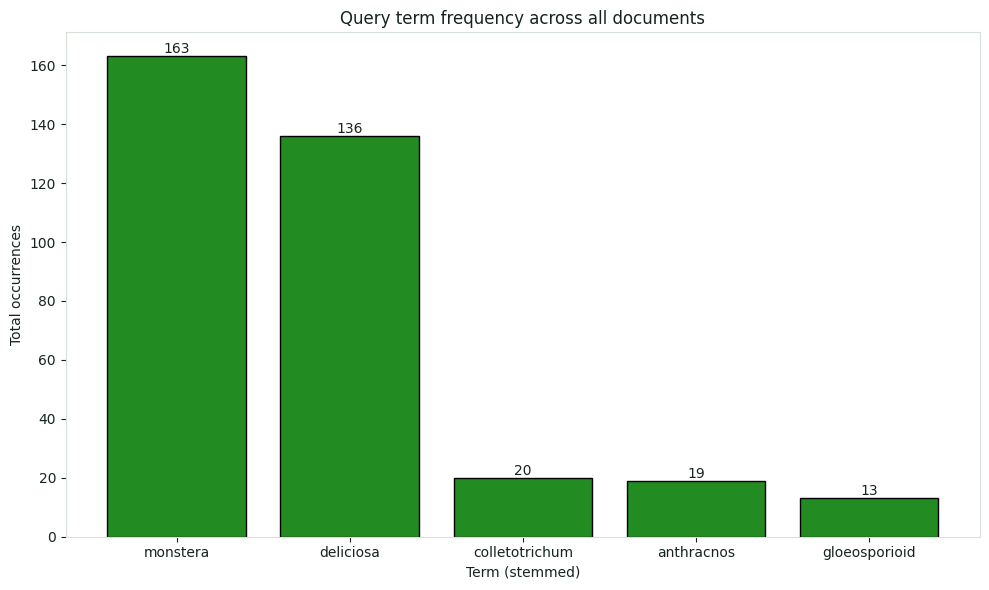

In [111]:
def plot_query_frequencies(query):
    """Bar chart of how often each query term appears across all documents"""
    terms = clean_tokens(tokenize(query))
    totals = {t: sum(freq[(t, d)] for d in lookup.get(t, [])) for t in terms}
    totals = {t: c for t, c in totals.items() if c > 0}
    if not totals:
        print("No query terms found in the index.")
        return

    items = sorted(totals.items(), key=lambda x: x[1], reverse=True)
    words, counts = zip(*items)

    plt.figure(figsize=(10, 6))
    bars = plt.bar(words, counts, color="forestgreen", edgecolor="black")
    plt.title("Query term frequency across all documents")
    plt.xlabel("Term (stemmed)")
    plt.ylabel("Total occurrences")
    for bar, c in zip(bars, counts):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 str(c), ha="center", va="bottom")
    plt.tight_layout()
    plt.show()

plot_query_frequencies("monstera deliciosa anthracnose colletotrichum gloeosporioides")

### **SCREENS AND IOT**

In [98]:
import json
import random
import datetime
import requests
import ipywidgets as widgets
import matplotlib.pyplot as plt
import paho.mqtt.client as mqtt
from IPython.display import display, Image, clear_output

In [100]:
# Realtime DB
DB_URL = "https://cloud-course-9c4ad-default-rtdb.europe-west1.firebasedatabase.app"

# Live IoT sensor server
SENSOR_SERVER = "https://server-cloud-v645.onrender.com/"

# Free public MQTT broker
MQTT_BROKER = "broker.hivemq.com"
MQTT_PORT = 1883
TEAM = "braude-team-chameleon"
MQTT_TOPIC = f"braude/plant/{TEAM}"

SENSOR_LOG = []     # readings, shared by sensor + dashboard screens
MQTT_MESSAGES = []  # messages received from the broker

# Healthy ranges, used by the dashboard to decide plant status
HEALTHY = {
    "temperature": (18, 30),   # Celsius
    "humidity": (40, 70),      # percent
    "soil_moisture": (30, 70), # percent
    "leaf_wetness": (0, 40),   # percent
}

In [101]:
def on_connect(client, userdata, flags, rc):
    client.subscribe(MQTT_TOPIC)
    print(f"MQTT connected (rc={rc}), subscribed to {MQTT_TOPIC}")

def on_message(client, userdata, msg):
    # background thread: only append
    try:
        payload = json.loads(msg.payload.decode())
    except Exception:
        payload = msg.payload.decode()
    MQTT_MESSAGES.append({"topic": msg.topic, "payload": payload})

# paho-mqtt 2.x needs the callback API version; fall back for 1.x
try:
    mqtt_client = mqtt.Client(mqtt.CallbackAPIVersion.VERSION1)
except (AttributeError, TypeError):
    mqtt_client = mqtt.Client()

mqtt_client.on_connect = on_connect
mqtt_client.on_message = on_message

try:
    mqtt_client.connect(MQTT_BROKER, MQTT_PORT, keepalive=60)
    mqtt_client.loop_start()  # background network thread
except Exception as e:
    print(f"MQTT connection failed: {e}")
    mqtt_client = None

def mqtt_publish(reading):
    """Publish one reading to the team topic. Safe if broker is down."""
    if mqtt_client is None:
        return
    try:
        mqtt_client.publish(MQTT_TOPIC, json.dumps(reading))
    except Exception as e:
        print(f"MQTT publish skipped: {e}")


/tmp/ipykernel_7876/2180815894.py:15: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  mqtt_client = mqtt.Client(mqtt.CallbackAPIVersion.VERSION1)


In [102]:
# Server feed names for each of our fields (None = no server feed, use local estimate)
_FEED_MAP = {
    "temperature": "temperature",
    "humidity":    "humidity",
    "soil_moisture": "soil",
    "leaf_wetness":  None,
}
_FEED_FALLBACK = {
    "temperature":  (15, 35),
    "humidity":     (30, 80),
    "soil_moisture":(20, 80),
    "leaf_wetness": (0,  60),
}

def read_sensors():
    """Fetch the latest value for each metric from the cloud server.
    Falls back to a random value for any metric that is unreachable or missing."""
    result = {"timestamp": datetime.datetime.now().strftime("%H:%M:%S")}
    for field, feed in _FEED_MAP.items():
        lo, hi = _FEED_FALLBACK[field]
        if feed is None:
            result[field] = round(random.uniform(lo, hi), 1)
            continue
        try:
            resp = requests.get(
                f"{SENSOR_SERVER}/history",
                params={"feed": feed, "limit": 1},
                timeout=10,
            )
            data = resp.json()
            if "data" in data and data["data"]:
                result[field] = round(float(data["data"][0]["value"]), 1)
            else:
                result[field] = round(random.uniform(lo, hi), 1)
        except Exception:
            result[field] = round(random.uniform(lo, hi), 1)
    return result

def load_history(limit=20, replace=False):
    """Fetch the last `limit` readings per feed from the server and populate SENSOR_LOG.
    If replace=True, always fetches fresh data. If replace=False, skips when SENSOR_LOG is non-empty."""
    global SENSOR_LOG
    if not replace and SENSOR_LOG:
        return 0

    feeds = {
        "temperature": "temperature",
        "humidity":    "humidity",
        "soil_moisture": "soil",
    }
    raw = {}
    for field, feed in feeds.items():
        try:
            resp = requests.get(
                f"{SENSOR_SERVER}/history",
                params={"feed": feed, "limit": limit},
                timeout=15,
            )
            result = resp.json()
            if "data" in result and result["data"]:
                raw[field] = result["data"]  # newest-first from server
        except Exception:
            pass

    if not raw:
        return 0

    ref_key = next(iter(raw))
    n = min(len(v) for v in raw.values())
    entries = []
    for i in range(n):
        ts_str = raw[ref_key][i].get("created_at", "")
        try:
            ts = datetime.datetime.fromisoformat(
                ts_str.replace("Z", "+00:00").replace(" UTC", "+00:00")
            ).strftime("%H:%M:%S")
        except Exception:
            ts = ts_str[:8] if len(ts_str) >= 8 else str(i)

        entry = {"timestamp": ts}
        for field in feeds:
            if field in raw and i < len(raw[field]):
                try:
                    entry[field] = round(float(raw[field][i]["value"]), 1)
                except Exception:
                    lo, hi = _FEED_FALLBACK[field]
                    entry[field] = round(random.uniform(lo, hi), 1)
            else:
                lo, hi = _FEED_FALLBACK[field]
                entry[field] = round(random.uniform(lo, hi), 1)

        lo, hi = _FEED_FALLBACK["leaf_wetness"]
        entry["leaf_wetness"] = round(random.uniform(lo, hi), 1)
        entries.append(entry)

    entries.reverse()  # convert to chronological order (oldest first)
    if replace:
        SENSOR_LOG.clear()
    SENSOR_LOG.extend(entries)
    return len(entries)

def push_to_firebase(reading):
    """Store one reading in the Firebase Realtime DB. Safe to skip if offline."""
    try:
        requests.post(f"{DB_URL}/sensor_readings.json", json=reading, timeout=10)
    except Exception as e:
        print(f"Firebase push skipped: {e}")

MQTT connected (rc=0), subscribed to braude/plant/braude-team-chameleon


In [103]:
import io
import json
import random
import datetime
import threading
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, HTML, Image, clear_output

#  Chameleaf - Precision Plant Monitoring (single-notebook app)

# ---- SAFE FALLBACKS ----
if "HEALTHY" not in globals():
    HEALTHY = {"temperature": (18, 30), "humidity": (40, 70),
               "soil_moisture": (30, 60), "leaf_wetness": (0, 40)}
if "SENSOR_LOG" not in globals():
    SENSOR_LOG = []
if "MQTT_MESSAGES" not in globals():
    MQTT_MESSAGES = []
if "MQTT_TOPIC" not in globals():
    MQTT_TOPIC = "greenhouse/zone-1/telemetry"
if "MQTT_BROKER" not in globals():
    MQTT_BROKER = "localhost:1883"
if "SENSOR_SERVER" not in globals():
    SENSOR_SERVER = "https://server-cloud-v645.onrender.com/"
if "read_sensors" not in globals():
    def read_sensors():
        return {"timestamp": datetime.datetime.now().strftime("%H:%M:%S"),
                "temperature": round(random.uniform(15, 33), 1),
                "humidity": round(random.uniform(35, 75), 1),
                "soil_moisture": round(random.uniform(25, 65), 1),
                "leaf_wetness": round(random.uniform(0, 50), 1)}
if "load_history" not in globals():
    def load_history(limit=20, replace=False):
        return 0
if "push_to_firebase" not in globals():
    def push_to_firebase(reading):
        return
if "mqtt_publish" not in globals():
    def mqtt_publish(reading):
        MQTT_MESSAGES.append({"payload": json.dumps(reading)})
if "WATERING" not in globals():
    WATERING = {"interval_hours": 24, "last_watered": None}

TEAM_NAME = globals().get("TEAM", "braude-team-chameleon")

UNITS = {"temperature": "C", "humidity": "%", "soil_moisture": "%", "leaf_wetness": "%"}
LABELS = {"temperature": "Temperature", "humidity": "Humidity",
          "soil_moisture": "Soil Moisture", "leaf_wetness": "Leaf Wetness"}
SHORT = {"temperature": "Temp", "humidity": "Humidity",
         "soil_moisture": "Soil", "leaf_wetness": "Leaf"}
METRIC_COLORS = {"temperature": "#ef4444", "humidity": "#2563eb",
                 "soil_moisture": "#16a34a", "leaf_wetness": "#9333ea"}
SCALE = {"temperature": (10, 40), "humidity": (0, 100),
         "soil_moisture": (0, 100), "leaf_wetness": (0, 100)}

# ---- THEME ----
APP_CSS = """
<style>
  @import url('https://fonts.googleapis.com/css2?family=Space+Grotesk:wght@500;600;700&family=DM+Sans:wght@400;500;600;700&display=swap');
  :root{
    --bg1:#eef7f1; --bg2:#f6fbf8; --panel:#ffffff;
    --border:#e4ece7; --text:#16241d; --muted:#5f726a;
    --accent:#16a34a; --accent-dim:#0f7a39; --accent-soft:#dcfce7;
    --amber:#d97706; --amber-soft:#fef3c7; --red:#dc2626; --red-soft:#fee2e2; --blue:#2563eb;
    --grad:linear-gradient(135deg,#16a34a,#34d399);
  }
  .cl-app{ background:radial-gradient(900px 420px at 0% -5%, #e3f6ea 0%, transparent 55%),
           linear-gradient(135deg,var(--bg1),var(--bg2));
           padding:18px; border-radius:18px; color:var(--text);
           font-family:'DM Sans',-apple-system,BlinkMacSystemFont,"Segoe UI",Roboto,sans-serif; }
  .cl-bar{ background:#fff; border:1px solid var(--border); border-radius:16px;
           padding:16px 20px; margin-bottom:14px; box-shadow:0 6px 18px rgba(18,40,28,.06); }
  .cl-mark{ width:30px; height:30px; border-radius:16px 4px 16px 4px; background:var(--grad);
           display:inline-block; box-shadow:0 4px 10px rgba(22,163,74,.35); }
  .cl-brand{ font-family:'Space Grotesk',sans-serif; color:var(--text); font-size:21px;
           font-weight:700; letter-spacing:.2px; line-height:1.1; }
  .cl-brand .leaf{ color:var(--accent); }
  .cl-sub{ color:var(--muted); font-size:10.5px; margin-top:3px; letter-spacing:1.4px; text-transform:uppercase; }
  .pill{ font-family:'Space Grotesk',sans-serif; font-size:12px; font-weight:600; padding:6px 14px;
         border-radius:999px; border:1px solid transparent; white-space:nowrap; }
  .pill-ok{ color:#fff; background:var(--grad); box-shadow:0 4px 10px rgba(22,163,74,.28); }
  .pill-warn{ color:#fff; background:linear-gradient(135deg,#f59e0b,#fbbf24); }
  .pill-idle{ color:var(--muted); background:#eef2f0; border-color:var(--border); }
  .panel{ background:var(--panel); border:1px solid var(--border); border-radius:18px;
          padding:26px; min-height:500px; box-sizing:border-box; display:flex; flex-direction:column;
          box-shadow:0 10px 30px rgba(18,40,28,.07); margin-top:12px; }
  .panel-title{ font-family:'Space Grotesk',sans-serif; color:var(--text); font-size:18px;
          font-weight:700; position:relative; padding-left:14px; margin-bottom:2px; }
  .panel-title::before{ content:""; position:absolute; left:0; top:2px; bottom:2px; width:5px;
          border-radius:3px; background:var(--grad); }
  .hint{ color:var(--muted); font-size:12px; margin-top:8px; line-height:1.5; }
  .muted{ color:var(--muted); }
  .row-label{ color:var(--muted); font-size:12px; font-weight:600; }
  .btn button, button.btn{ background:#fff!important; color:var(--text)!important;
        border:1px solid var(--border)!important; border-radius:10px!important;
        font-family:'DM Sans',sans-serif!important; font-size:12px!important; height:38px!important;
        font-weight:600!important; box-shadow:0 1px 2px rgba(18,40,28,.05)!important; transition:all .15s ease!important; }
  .btn button:hover, button.btn:hover{ border-color:var(--accent)!important; color:var(--accent-dim)!important; }
  .btn-primary button, button.btn-primary{ background:var(--grad)!important; border:none!important;
        color:#fff!important; box-shadow:0 5px 14px rgba(22,163,74,.30)!important; }
  .btn-primary button:hover, button.btn-primary:hover{ filter:brightness(1.06); }
  .chip button, button.chip{ height:32px!important; width:auto!important; min-width:0!important;
        font-size:11px!important; padding:0 15px!important; border-radius:999px!important;
        color:var(--accent-dim)!important; background:var(--accent-soft)!important;
        border:1px solid #bfe6cb!important; box-shadow:none!important; font-weight:600!important;
        white-space:nowrap!important; overflow:visible!important; text-overflow:clip!important; }
  .chip button:hover, button.chip:hover{ background:#cdeed7!important; }
  .field input{ background:#fff!important; color:var(--text)!important;
        border:1px solid var(--border)!important; border-radius:10px!important; height:38px!important;
        font-family:'DM Sans',sans-serif!important; }
  .field input:focus{ border-color:var(--accent)!important; box-shadow:0 0 0 3px rgba(22,163,74,.12)!important; }
  .field input::placeholder{ color:var(--muted)!important; opacity:1; }
  .banner{ border-radius:12px; padding:14px 16px; font-family:'Space Grotesk',sans-serif; font-weight:600;
        font-size:14px; margin-bottom:18px; border:1px solid var(--border); border-left-width:5px; }
  .banner-ok{ background:var(--accent-soft); color:var(--accent-dim); border-left-color:var(--accent); }
  .banner-warn{ background:var(--amber-soft); color:#b45309; border-left-color:var(--amber); }
  .banner-idle{ background:#eef2f0; color:var(--muted); border-left-color:var(--muted); }
  .vitals{ display:flex; flex-direction:column; gap:20px; margin-bottom:20px; }
  .vital-top{ display:flex; justify-content:space-between; align-items:center; margin-bottom:9px; }
  .vital-name{ color:var(--text); font-weight:600; font-size:13px; }
  .vital-right{ display:flex; align-items:center; gap:9px; }
  .vital-val{ font-family:'Space Grotesk',sans-serif; font-weight:700; font-size:18px; }
  .v-pill{ font-size:10px; font-weight:700; padding:2px 9px; border-radius:999px; letter-spacing:.5px;
        white-space:nowrap; }
  .v-pill.ok{ background:var(--accent-soft); color:var(--accent-dim); }
  .v-pill.bad{ background:var(--red-soft); color:var(--red); }
  .v-pill.info{ background:#eef2f0; color:var(--muted); }
  .vbar{ position:relative; height:12px; }
  .vtrack{ position:absolute; inset:0; border-radius:999px; overflow:hidden;
        background:#eef2f0; border:1px solid #e4ece7; }
  .vzone{ position:absolute; top:0; bottom:0; }
  .vzone.low{ background:rgba(220,38,38,.14); }
  .vzone.health{ background:rgba(22,163,74,.34); }
  .vzone.high{ background:rgba(217,119,6,.20); }
  .vneedle{ position:absolute; top:-4px; bottom:-4px; width:3px; border-radius:2px;
        background:#16241d; transform:translateX(-50%); box-shadow:0 0 0 2px #fff; }
  .vscale{ display:flex; justify-content:space-between; color:#94a3b8; font-size:10px; margin-top:6px; }
  .vscale-mid{ color:var(--accent-dim); font-weight:600; }
  .meta{ display:flex; flex-wrap:wrap; gap:12px 30px; padding-top:16px; border-top:1px solid var(--border); }
  .meta-k{ color:#94a3b8; font-size:10.5px; letter-spacing:.6px; text-transform:uppercase; display:block; }
  .meta-v{ color:var(--text); font-size:13px; font-weight:600; margin-top:3px; display:block; }
  .cl-empty{ color:var(--muted); font-size:13px; padding:4px 0; }
  .ro-title{ font-family:'Space Grotesk',sans-serif; font-weight:700; font-size:14px; color:var(--text); margin:2px 0 12px; }
  .ro-grid{ display:flex; flex-wrap:wrap; gap:10px; }
  .ro-item{ flex:1 1 180px; display:flex; align-items:center; gap:10px; background:#f7faf8;
        border:1px solid var(--border); border-radius:12px; padding:11px 14px; }
  .ro-k{ color:var(--muted); font-size:12px; font-weight:600; }
  .ro-v{ font-family:'Space Grotesk',sans-serif; font-weight:700; font-size:15px; margin-left:auto; }
  .ro-line{ font-size:14px; color:var(--text); display:flex; align-items:center; gap:10px; margin-bottom:6px; }
  .note{ color:var(--muted); font-size:12px; margin-top:14px; line-height:1.5; }
  .msg-list{ display:flex; flex-direction:column; gap:8px; }
  .msg-line{ background:#f7faf8; border:1px solid var(--border); border-radius:10px; padding:9px 12px;
        font-size:13px; color:var(--text); }
  .msg-time{ color:var(--accent-dim); font-weight:700; margin-right:8px; }
  .rtable{ width:100%; border-collapse:collapse; }
  .rtable th{ text-align:left; color:var(--muted); font-size:10.5px; letter-spacing:.5px;
        text-transform:uppercase; padding:8px 10px; border-bottom:1px solid var(--border); }
  .rtable td{ padding:10px; border-bottom:1px solid #f0f4f1; font-size:13px; color:var(--text); }
  .rtable .num{ font-family:'Space Grotesk',sans-serif; font-weight:700; }
  .rtable tr:last-child td{ border-bottom:none; }
  .cl-drop{ border:2px dashed #bfe0c9; border-radius:16px;
        background:linear-gradient(180deg,#f4fbf6,#fbfdfc); padding:28px; text-align:center; margin:10px 0 14px; }
  .cl-drop-title{ font-family:'Space Grotesk',sans-serif; font-weight:600; color:var(--text); margin-top:4px; }
  .cl-upicon{ width:48px; height:48px; border-radius:50%; background:var(--accent-soft); position:relative; margin:0 auto 10px; }
  .cl-upicon::before{ content:""; position:absolute; left:50%; top:15px; transform:translateX(-50%);
        border-left:7px solid transparent; border-right:7px solid transparent; border-bottom:10px solid var(--accent); }
  .cl-upicon::after{ content:""; position:absolute; left:50%; top:24px; transform:translateX(-50%);
        width:4px; height:11px; background:var(--accent); }
  .pg-foot{ color:var(--muted); font-size:11px; text-align:center; margin-top:16px; letter-spacing:.4px; }
  .widget-tab > .p-TabBar, .widget-tab > .lm-TabBar{ background:#eef4f0!important;
        border:1px solid var(--border)!important; border-radius:14px!important; padding:5px!important; }
  .widget-tab .p-TabBar-tab, .widget-tab .lm-TabBar-tab{
        background:transparent!important; color:var(--muted)!important; border:none!important;
        box-shadow:none!important; outline:none!important; margin:0 2px!important; border-radius:10px!important;
        padding:8px 18px!important; font-family:'Space Grotesk',sans-serif!important; font-weight:600!important;
        transition:all .15s ease!important; }
  .widget-tab .p-TabBar-tab::before, .widget-tab .lm-TabBar-tab::before,
  .widget-tab .p-TabBar-tab::after, .widget-tab .lm-TabBar-tab::after{ display:none!important; }
  .widget-tab .p-TabBar-tab:hover, .widget-tab .lm-TabBar-tab:hover{ color:var(--accent-dim)!important; }
  .widget-tab .p-TabBar-tab.p-mod-current, .widget-tab .lm-TabBar-tab.lm-mod-current,
  .jupyter-widgets.widget-tab .p-TabBar-tab.p-mod-current,
  .jupyter-widgets.widget-tab .lm-TabBar-tab.lm-mod-current{
        background:var(--grad)!important; color:#fff!important; border:none!important; border-top:none!important;
        box-shadow:0 5px 14px rgba(22,163,74,.30)!important; }
  .widget-tab .p-TabBar-tabLabel, .widget-tab .lm-TabBar-tabLabel{ color:inherit!important; }
</style>
"""
display(HTML(APP_CSS))

plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "#ffffff", "axes.facecolor": "#ffffff",
    "axes.edgecolor": "#d7e0d9", "text.color": "#16241d",
    "axes.labelcolor": "#16241d", "xtick.color": "#16241d", "ytick.color": "#16241d",
})


# ---- AUTO-REFRESH STATE ----
_refresh_state = {"active": False, "thread": None, "stop_event": None}

def _start_auto_refresh(interval_secs):
    _stop_auto_refresh()
    _refresh_state["active"] = True
    _refresh_state["interval"] = interval_secs
    stop_event = threading.Event()
    _refresh_state["stop_event"] = stop_event

    def _worker():
        while not stop_event.wait(interval_secs):
            if not _refresh_state["active"]:
                break
            try:
                record_reading()
            except Exception:
                pass

    t = threading.Thread(target=_worker, daemon=True)
    _refresh_state["thread"] = t
    t.start()

def _stop_auto_refresh():
    _refresh_state["active"] = False
    if _refresh_state.get("stop_event"):
        _refresh_state["stop_event"].set()
    _refresh_state["thread"] = None


# ---- SHARED STATE / HELPERS ----
def _overall_status():
    if not SENSOR_LOG:
        return ("idle", "NO DATA")
    latest = SENSOR_LOG[-1]
    problems = [k for k, (lo, hi) in HEALTHY.items()
                if k in latest and not (lo <= latest[k] <= hi)]
    return ("ok", "HEALTHY") if not problems else ("warn", "NEEDS ATTENTION")

def _chip(ok):
    return f"<span class='v-pill {'ok' if ok else 'bad'}'>{'OK' if ok else 'OUT'}</span>"

def _fmt_td(td):
    return str(td).split(".")[0]

def _schedule_text():
    if WATERING["last_watered"] is None:
        return f"Watering every {WATERING['interval_hours']}h. No watering logged yet."
    nxt = WATERING["last_watered"] + datetime.timedelta(hours=WATERING["interval_hours"])
    return (f"Watering every {WATERING['interval_hours']}h. "
            f"Last watered {WATERING['last_watered'].strftime('%Y-%m-%d %H:%M')}, "
            f"next due {nxt.strftime('%Y-%m-%d %H:%M')}.")

def _show_fig(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    display(Image(data=buf.read()))

APP_STATUS = widgets.HTML()
HOME_BODY = widgets.HTML()

def refresh_app_status():
    cls, label = _overall_status()
    pill = {"ok": "pill-ok", "warn": "pill-warn", "idle": "pill-idle"}[cls]
    APP_STATUS.value = f"<span class='pill {pill}'>{label}</span>"

def _vitals_html():
    if not SENSOR_LOG:
        return "<div class='cl-empty'>No readings yet. Press <b>Sample a reading</b> to begin.</div>"
    latest = SENSOR_LOG[-1]
    def pct(x, m):
        smin, smax = SCALE[m]
        return max(0.0, min(100.0, (x - smin) / (smax - smin) * 100.0))
    rows = []
    for m, (lo, hi) in HEALTHY.items():
        v = latest.get(m)
        if v is None:
            continue
        smin, smax = SCALE[m]
        leftP, rightP, posP = pct(lo, m), pct(hi, m), pct(v, m)
        if v < lo:
            status, scls = "LOW", "bad"
        elif v > hi:
            status, scls = "HIGH", "bad"
        else:
            status, scls = "OK", "ok"
        valcolor = "#16a34a" if scls == "ok" else "#dc2626"
        rows.append(
            f"<div class='vital'>"
            f"<div class='vital-top'><span class='vital-name'>{LABELS[m]}</span>"
            f"<span class='vital-right'>"
            f"<span class='vital-val' style='color:{valcolor}'>{v}{UNITS[m]}</span>"
            f"<span class='v-pill {scls}'>{status}</span></span></div>"
            f"<div class='vbar'><div class='vtrack'>"
            f"<div class='vzone low' style='left:0;width:{leftP}%'></div>"
            f"<div class='vzone health' style='left:{leftP}%;width:{max(0, rightP - leftP)}%'></div>"
            f"<div class='vzone high' style='left:{rightP}%;width:{max(0, 100 - rightP)}%'></div>"
            f"</div><div class='vneedle' style='left:{posP}%'></div></div>"
            f"<div class='vscale'><span>{smin}{UNITS[m]}</span>"
            f"<span class='vscale-mid'>healthy {lo}-{hi}{UNITS[m]}</span>"
            f"<span>{smax}{UNITS[m]}</span></div></div>")
    return "<div class='vitals'>" + "".join(rows) + "</div>"

def _meta_html():
    if WATERING["last_watered"] is None:
        water = "no watering logged yet"
    else:
        nxt = WATERING["last_watered"] + datetime.timedelta(hours=WATERING["interval_hours"])
        water = f"next due {nxt.strftime('%Y-%m-%d %H:%M')}"
    auto_str = (f"auto-refresh every {_refresh_state.get('interval', 30)}s"
                if _refresh_state["active"] else "auto-refresh off")
    return (f"<div class='meta'>"
            f"<div><span class='meta-k'>Irrigation</span>"
            f"<span class='meta-v'>{water}</span></div>"
            f"<div><span class='meta-k'>Telemetry</span>"
            f"<span class='meta-v'>{len(SENSOR_LOG)} readings, {len(MQTT_MESSAGES)} messages</span></div>"
            f"<div><span class='meta-k'>Polling</span>"
            f"<span class='meta-v'>{auto_str}</span></div>"
            f"</div>")

def _home_html():
    cls, label = _overall_status()
    banner_cls = "banner-ok" if cls == "ok" else ("banner-warn" if cls == "warn" else "banner-idle")
    banner = f"<div class='banner {banner_cls}'>PLANT STATUS: {label}</div>"
    return banner + _vitals_html() + _meta_html()

def refresh_home():
    HOME_BODY.value = _home_html()
    refresh_app_status()

def record_reading():
    reading = read_sensors()
    SENSOR_LOG.append(reading)
    push_to_firebase(reading)
    mqtt_publish(reading)
    refresh_home()
    return reading


def _iter_uploads(uploader):
    val = uploader.value
    if isinstance(val, dict):
        for name, info in val.items():
            yield name, info["content"]
    else:
        for info in val:
            yield info["name"], info["content"]

def _reset_uploader(uploader):
    try:
        uploader.value = type(uploader.value)()
    except Exception:
        pass

def _reading_readout_html(reading):
    items = ""
    for k in HEALTHY:
        v = reading.get(k)
        lo, hi = HEALTHY[k]
        ok = v is not None and lo <= v <= hi
        items += (f"<div class='ro-item'><span class='ro-k'>{LABELS[k]}</span>"
                  f"<span class='ro-v'>{v}{UNITS[k]}</span>{_chip(ok)}</div>")
    src_note = "Live data from cloud server (leaf wetness estimated locally)."
    return (f"<div class='ro-title'>Latest reading</div><div class='ro-grid'>{items}</div>"
            f"<div class='note'>{src_note} Saved to Firebase and published to MQTT. "
            f"{len(SENSOR_LOG)} reading(s) stored. Open Overview or Trends to view them.</div>")

def _messages_readout_html():
    if not MQTT_MESSAGES:
        return "<div class='cl-empty'>No messages received yet. Sample a reading first.</div>"
    lines = ""
    for msg in MQTT_MESSAGES[-10:]:
        payload = msg.get("payload") if isinstance(msg, dict) else msg
        if isinstance(payload, str):
            try:
                payload = json.loads(payload)
            except Exception:
                payload = None
        if isinstance(payload, dict):
            t = payload.get("timestamp", "")
            parts = [f"{SHORT[k]} {payload[k]}{UNITS[k]}" for k in HEALTHY if k in payload]
            lines += (f"<div class='msg-line'><span class='msg-time'>{t}</span>"
                      f"{', '.join(parts)}</div>")
        else:
            lines += f"<div class='msg-line'>{payload}</div>"
    return (f"<div class='ro-title'>Recent broker messages</div><div class='msg-list'>{lines}</div>"
            f"<div class='note'>Showing the latest {min(10, len(MQTT_MESSAGES))} of "
            f"{len(MQTT_MESSAGES)} on {MQTT_TOPIC}.</div>")

def _ranges_table_html():
    latest = SENSOR_LOG[-1]
    rows = ""
    for k in HEALTHY:
        v = latest.get(k)
        lo, hi = HEALTHY[k]
        ok = v is not None and lo <= v <= hi
        rows += (f"<tr><td>{LABELS[k]}</td><td class='num'>{v}{UNITS[k]}</td>"
                 f"<td>{lo}-{hi}{UNITS[k]}</td><td>{_chip(ok)}</td></tr>")
    return (f"<table class='rtable'><thead><tr><th>Metric</th><th>Current</th>"
            f"<th>Healthy</th><th>State</th></tr></thead><tbody>{rows}</tbody></table>")


# ---- Tab: Overview ----
def screen_home():
    sample_btn = widgets.Button(description="Sample a reading",
                                tooltip="Fetch a live reading and update the dashboard")
    sample_btn.add_class("btn"); sample_btn.add_class("btn-primary")
    refresh_btn = widgets.Button(description="Refresh",
                                 tooltip="Recompute status from the latest stored reading")
    refresh_btn.add_class("btn")

    sample_btn.on_click(lambda _: record_reading())
    refresh_btn.on_click(lambda _: refresh_home())

    title = widgets.HTML(
        "<div class='panel-title'>Overview</div>"
        "<div class='hint'>Live plant status. Historical data is pre-loaded from the cloud server. "
        "Use the Sensors tab to control auto-refresh.</div>")
    controls = widgets.HBox([sample_btn, widgets.HTML("&nbsp;"), refresh_btn])
    panel = widgets.VBox([title, controls, HOME_BODY])
    panel.add_class("panel")
    return panel


# ---- Tab: Image ----
def screen_image_upload():
    uploader = widgets.FileUpload(accept="image/*", multiple=False)
    uploader.add_class("btn")
    clear_btn = widgets.Button(description="Clear"); clear_btn.add_class("btn")
    out = widgets.Output()

    drop = widgets.HTML(
        "<div class='cl-drop'><div class='cl-upicon'></div>"
        "<div class='cl-drop-title'>Upload a plant image</div>"
        "<div class='hint'>Click Upload to choose a single image file (PNG or JPG)</div></div>")

    def on_upload(change):
        with out:
            clear_output(wait=True)
            for fname, content in _iter_uploads(uploader):
                display(HTML(f"<div class='note' style='margin:0 0 10px;'>Uploaded "
                             f"<b>{fname}</b> ({len(content)/1024:.1f} KB)</div>"))
                display(Image(data=content, width=320))

    def on_clear(_):
        _reset_uploader(uploader)
        out.clear_output()

    uploader.observe(on_upload, names="value")
    clear_btn.on_click(on_clear)

    title = widgets.HTML("<div class='panel-title'>Plant Image Upload</div>"
                         "<div class='hint'>Upload a photo of your plant. A new upload replaces the preview.</div>")
    controls = widgets.HBox([uploader, widgets.HTML("&nbsp;"), clear_btn])
    panel = widgets.VBox([title, drop, controls, out])
    panel.add_class("panel")
    return panel


# ---- Tab: Sensors ----
def screen_sensors():
    sample_btn = widgets.Button(description="Sample sensors",
                                tooltip="Fetch a live reading, save to Firebase, publish to MQTT")
    sample_btn.add_class("btn"); sample_btn.add_class("btn-primary")
    msgs_btn = widgets.Button(description="View messages",
                              tooltip="Show recent readings received from the MQTT broker")
    msgs_btn.add_class("btn")
    clear_btn = widgets.Button(description="Clear"); clear_btn.add_class("btn")

    interval_dd = widgets.Dropdown(
        options=[("30 seconds", 30), ("1 minute", 60), ("2 minutes", 120), ("5 minutes", 300)],
        value=30, layout=widgets.Layout(width="130px"))
    auto_btn = widgets.Button(description="Start auto-refresh", tooltip="Poll the server on a schedule")
    auto_btn.add_class("btn")
    auto_status = widgets.HTML("<span class='v-pill info' style='font-size:11px'>AUTO: OFF</span>")

    body = widgets.HTML("<div class='cl-empty'>Press <b>Sample sensors</b> to take your first reading.</div>")

    def _sync_auto_ui():
        if _refresh_state["active"]:
            auto_btn.description = "Stop auto-refresh"
            auto_status.value = "<span class='v-pill ok' style='font-size:11px'>AUTO: ON</span>"
        else:
            auto_btn.description = "Start auto-refresh"
            auto_status.value = "<span class='v-pill info' style='font-size:11px'>AUTO: OFF</span>"

    def on_sample(_):
        try:
            reading = record_reading()
            body.value = _reading_readout_html(reading)
        except Exception as e:
            body.value = f"<div class='cl-empty'>Could not read sensors: {e}</div>"

    def on_msgs(_):
        body.value = _messages_readout_html()

    def on_clear(_):
        body.value = ("<div class='cl-empty'>Press <b>Sample sensors</b> to take a reading, "
                      f"or <b>View messages</b> to see broker traffic. {len(SENSOR_LOG)} reading(s) stored.</div>")

    def on_auto(_):
        if _refresh_state["active"]:
            _stop_auto_refresh()
        else:
            _start_auto_refresh(int(interval_dd.value))
        _sync_auto_ui()
        refresh_home()

    sample_btn.on_click(on_sample)
    msgs_btn.on_click(on_msgs)
    clear_btn.on_click(on_clear)
    auto_btn.on_click(on_auto)

    title = widgets.HTML("<div class='panel-title'>IoT Sensor Sampling</div>"
                         f"<div class='hint'>Fetches live data from the cloud server "
                         f"(temperature, humidity, soil moisture), saves to Firebase, and publishes to "
                         f"MQTT topic <b>{MQTT_TOPIC}</b>. Leaf wetness is estimated locally.</div>")
    row1 = widgets.HBox([sample_btn, widgets.HTML("&nbsp;"), msgs_btn,
                         widgets.HTML("&nbsp;"), clear_btn])
    row2 = widgets.HBox([widgets.HTML("<span class='row-label'>Auto-refresh:</span>"),
                         widgets.HTML("&nbsp;"), interval_dd,
                         widgets.HTML("&nbsp;"), auto_btn,
                         widgets.HTML("&nbsp;"), auto_status])
    row2.layout.align_items = "center"
    body_box = widgets.VBox([body]); body_box.layout.margin = "16px 0 0 0"
    panel = widgets.VBox([title, row1, row2, body_box])
    panel.add_class("panel")
    return panel


# ---- Tab: Search ----
def screen_search():
    box = widgets.Text(placeholder="Search the indexed papers, e.g. fungus leaf disease")
    box.add_class("field"); box.layout.width = "60%"
    go_btn = widgets.Button(description="Search"); go_btn.add_class("btn"); go_btn.add_class("btn-primary")
    clear_btn = widgets.Button(description="Clear"); clear_btn.add_class("btn")
    out = widgets.Output()

    def _start(msg):
        with out:
            clear_output(wait=True)
            display(HTML(f"<div class='cl-empty'>{msg}</div>"))

    def on_search(_):
        q = box.value.strip()
        with out:
            clear_output(wait=True)
            if not q:
                display(HTML("<div class='cl-empty'>Type a query, or tap an example below.</div>"))
                return
            if "rag_display" in globals():
                display(HTML(f"<div class='ro-title'>Results for &lsquo;{q}&rsquo;</div>"))
                rag_display(q)
            else:
                display(HTML("<div class='cl-empty'>Search index not loaded yet. "
                             "Run the Part-1 cells above first.</div>"))

    def on_clear(_):
        box.value = ""
        _start("Type a query above or tap an example, then press Search.")

    go_btn.on_click(on_search)
    clear_btn.on_click(on_clear)
    try:
        box.on_submit(on_search)
    except Exception:
        pass

    examples = ["fungus leaf disease", "monstera deliciosa", "water use efficiency", "influence chemical"]
    chips = []
    def _chip_handler(query):
        def h(_):
            box.value = query
            on_search(None)
        return h
    for ex in examples:
        b = widgets.Button(description=ex)
        b.add_class("btn"); b.add_class("chip"); b.layout.width = "auto"
        b.on_click(_chip_handler(ex))
        chips.append(b)

    title = widgets.HTML("<div class='panel-title'>Search Engine</div>"
                         "<div class='hint'>Search the indexed plant-disease research papers.</div>")
    controls = widgets.HBox([box, widgets.HTML("&nbsp;"), go_btn, widgets.HTML("&nbsp;"), clear_btn])
    controls.layout.align_items = "center"
    example_row = widgets.HBox([widgets.HTML("<span class='row-label'>Try:</span>"),
                                widgets.HTML("&nbsp;")] + chips)
    example_row.layout.align_items = "center"; example_row.layout.flex_flow = "row wrap"
    out_box = widgets.VBox([out]); out_box.layout.margin = "16px 0 0 0"
    panel = widgets.VBox([title, controls, example_row, out_box])
    panel.add_class("panel")
    _start("Type a query above or tap an example, then press Search.")
    return panel


# ---- Tab: Trends ----
def screen_trends():
    refresh_btn = widgets.Button(description="Refresh trends",
                                 tooltip="Plot all readings including manually sampled ones")
    refresh_btn.add_class("btn"); refresh_btn.add_class("btn-primary")
    clear_btn = widgets.Button(description="Clear"); clear_btn.add_class("btn")
    out = widgets.Output()

    def _render():
        display(HTML(_ranges_table_html()))
        window = SENSOR_LOG[-20:]
        times = [r.get("timestamp", str(i)) for i, r in enumerate(window)]
        fig, ax = plt.subplots(figsize=(9, 3.4))
        for m in HEALTHY:
            if not all(m in r for r in window):
                continue
            ax.plot(times, [r[m] for r in window], marker="o",
                    label=LABELS.get(m, m), color=METRIC_COLORS.get(m, "#16a34a"),
                    linewidth=1.8, markersize=4)
        ax.set_xlabel("Time"); ax.set_ylabel("Value")
        ax.set_title(f"Sensor history (last {len(window)} readings)")
        ax.grid(color="#e3eae5", linewidth=0.8)
        ax.legend(loc="upper right", fontsize=8, frameon=True,
                  facecolor="#ffffff", edgecolor="#e3eae5", labelcolor="#16241d")
        for lbl in ax.get_xticklabels():
            lbl.set_rotation(45); lbl.set_ha("right")
        fig.tight_layout()
        _show_fig(fig)

    def on_refresh(_):
        # If we have no data at all, do a one-time server fetch first.
        if not SENSOR_LOG:
            with out:
                clear_output(wait=True)
                display(HTML("<div class='cl-empty'>Fetching history from the cloud server...</div>"))
            n = load_history(limit=30, replace=False)
            refresh_home()
            if n == 0:
                with out:
                    clear_output(wait=True)
                    display(HTML("<div class='cl-empty'>Server did not return data. "
                                 "Check the connection and try again.</div>"))
                return
        # Render whatever is in SENSOR_LOG (server history + any manual samples).
        with out:
            clear_output(wait=True)
            display(HTML(f"<div class='note'>{len(SENSOR_LOG)} readings in chart "
                         f"(server history + manual samples).</div>"))
            _render()

    def on_clear(_):
        with out:
            clear_output(wait=True)
            display(HTML("<div class='cl-empty'>Press 'Refresh trends' to plot all readings.</div>"))

    refresh_btn.on_click(on_refresh)
    clear_btn.on_click(on_clear)

    title = widgets.HTML("<div class='panel-title'>Trends and Analytics</div>"
                         "<div class='hint'>Plots all readings in the current session: server history "
                         "pre-loaded at startup plus any readings sampled manually.</div>")
    controls = widgets.HBox([refresh_btn, widgets.HTML("&nbsp;"), clear_btn])
    out_box = widgets.VBox([out]); out_box.layout.margin = "16px 0 0 0"
    panel = widgets.VBox([title, controls, out_box])
    panel.add_class("panel")
    with out:
        display(HTML("<div class='cl-empty'>Press 'Refresh trends' to plot all readings.</div>"))
    return panel


# ---- Tab: Care ----
def screen_care():
    interval = widgets.BoundedIntText(value=WATERING["interval_hours"], min=1, max=168)
    interval.add_class("field"); interval.layout.width = "90px"
    set_btn = widgets.Button(description="Set interval"); set_btn.add_class("btn")
    water_btn = widgets.Button(description="Mark as watered")
    water_btn.add_class("btn"); water_btn.add_class("btn-primary")
    check_btn = widgets.Button(description="Check status"); check_btn.add_class("btn")
    body = widgets.HTML(f"<div class='cl-empty'>{_schedule_text()}</div>")

    def on_set(_):
        WATERING["interval_hours"] = int(interval.value)
        refresh_home()
        body.value = (f"<div class='ro-line'><span class='v-pill ok'>SAVED</span>"
                      f"Interval set to every {WATERING['interval_hours']}h.</div>"
                      f"<div class='note'>{_schedule_text()}</div>")

    def on_water(_):
        WATERING["last_watered"] = datetime.datetime.now()
        refresh_home()
        body.value = (f"<div class='ro-line'><span class='v-pill ok'>WATERED</span>"
                      f"Logged a watering just now.</div>"
                      f"<div class='note'>{_schedule_text()}</div>")

    def on_check(_):
        rows = ""
        if SENSOR_LOG:
            soil = SENSOR_LOG[-1].get("soil_moisture")
            lo = HEALTHY["soil_moisture"][0]
            if soil is not None and soil < lo:
                rows += (f"<div class='ro-line'><span class='v-pill bad'>DRY</span>"
                         f"Soil moisture {soil}% is below the healthy minimum {lo}%. Water now.</div>")
        if WATERING["last_watered"] is None:
            rows += ("<div class='ro-line'><span class='v-pill info'>NO SCHEDULE</span>"
                     "No watering logged yet. Press Mark as watered to start.</div>")
        else:
            nxt = WATERING["last_watered"] + datetime.timedelta(hours=WATERING["interval_hours"])
            remaining = nxt - datetime.datetime.now()
            if remaining.total_seconds() <= 0:
                rows += (f"<div class='ro-line'><span class='v-pill bad'>DUE</span>"
                         f"Watering is overdue by {_fmt_td(-remaining)}.</div>")
            else:
                rows += (f"<div class='ro-line'><span class='v-pill ok'>ON TRACK</span>"
                         f"Not due yet, {_fmt_td(remaining)} remaining.</div>")
        body.value = rows + f"<div class='note'>{_schedule_text()}</div>"

    set_btn.on_click(on_set)
    water_btn.on_click(on_water)
    check_btn.on_click(on_check)

    title = widgets.HTML("<div class='panel-title'>Care Scheduler</div>"
                         "<div class='hint'>Set a watering interval, log waterings, and get a due / not-due "
                         "reminder. A dry soil-moisture reading raises an immediate alert.</div>")
    row1 = widgets.HBox([widgets.HTML("<span class='row-label'>Water every (hours):</span>"),
                         widgets.HTML("&nbsp;"), interval, widgets.HTML("&nbsp;"), set_btn])
    row1.layout.align_items = "center"
    row2 = widgets.HBox([water_btn, widgets.HTML("&nbsp;"), check_btn])
    body_box = widgets.VBox([body]); body_box.layout.margin = "16px 0 0 0"
    panel = widgets.VBox([title, row1, row2, body_box])
    panel.add_class("panel")
    return panel


# ---- ASSEMBLE THE APPLICATION ----
brand = widgets.HTML(
    "<div style='display:flex;align-items:center;gap:12px;'>"
    "<span class='cl-mark'></span>"
    "<div><div class='cl-brand'>Chame<span class='leaf'>leaf</span></div>"
    "<div class='cl-sub'>Plant Monitoring</div></div></div>")
app_bar = widgets.HBox([brand, APP_STATUS])
app_bar.add_class("cl-bar")
app_bar.layout.justify_content = "space-between"
app_bar.layout.align_items = "center"

tabs = widgets.Tab(children=[
    screen_home(),
    screen_image_upload(),
    screen_sensors(),
    screen_search(),
    screen_trends(),
    screen_care(),
])
for i, t in enumerate(["Overview", "Image", "Sensors", "Search", "Trends", "Care"]):
    tabs.set_title(i, t)



app = widgets.VBox([app_bar, tabs])
app.add_class("cl-app")

# Pre-load historical data from the server (only runs when SENSOR_LOG is empty)
_n_history = load_history(20)

refresh_home()
display(app)